In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install video-diffusion-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 62.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
# Path to your new conditional diffusion model checkpoint
CKPT_PATH = '/content/drive/MyDrive/Model training/cloud_motion_diffusion_full_3D_UNet_final.pth'

# Folder where your .h5 files live
DATA_FOLDER = '/content/drive/MyDrive/3DS_resized_96_1/'

import glob
all_h5_paths = sorted(glob.glob(DATA_FOLDER + '*.h5'))
print(f"Found {len(all_h5_paths)} files")


Found 96 files


In [ ]:
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# List of spectral bands to load
band_list = ['IMG_VIS', 'IMG_WV', 'IMG_TIR1', 'IMG_TIR2', 'IMG_MIR', 'IMG_SWIR']

# Function to load 1 sample = sequence of 8 timesteps (frames)
def load_sequence(h5_file_paths, bands, sequence_length=8):
    sequence = []
    for path in h5_file_paths[:sequence_length]:
        with h5py.File(path, 'r') as f:
            frame = [f[band][0] for band in bands]  # (6, 128, 128)
            sequence.append(np.stack(frame))  # (6, 128, 128)
    return torch.tensor(np.stack(sequence), dtype=torch.float32)  # (8, 6, 128, 128)

# PyTorch Dataset class
class CloudMotionDataset(Dataset):


    def __init__(self, h5_file_paths, bands, sequence_length):
        self.paths = h5_file_paths
        self.bands = bands
        self.seq_len = sequence_length

        self.valid_start_indices = list(range(0, len(h5_file_paths) - sequence_length + 1))
        self.starts = list(range(len(h5_file_paths) - sequence_length + 1))  # ✅ FIXED variable names


    def __len__(self):
        return len(self.valid_start_indices)


    def __getitem__(self, i):
        sp = self.starts[i]
        x = load_sequence(self.paths[sp:sp+self.seq_len], self.bands, self.seq_len)  # (8,6,128,128)

        # Normalize each band independently to [–1, 1]
        x_reshaped = x.permute(1, 0, 2, 3).reshape(6, -1)  # (6, N)
        mins = x_reshaped.min(dim=1, keepdim=True)[0]
        maxs = x_reshaped.max(dim=1, keepdim=True)[0]
        norm = (x_reshaped - mins) / (maxs - mins + 1e-5)
        norm = norm * 2 - 1
        x_norm = norm.view(6, self.seq_len, 128, 128).permute(1, 0, 2, 3)  # (8,6,128,128)

        # Conditional setup: split into 6 input + 2 output
        cond = x_norm[:6]     # (6, 6, 128, 128)
        target = x_norm[6:]   # (2, 6, 128, 128)

        return cond, target




# Create dataset instance
dataset = CloudMotionDataset(all_h5_paths, band_list, sequence_length=8)  # ✅ Fixed



In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/Model training/cloud_motion_diffusion_full_3D_UNet_final.pth")
print("✅ Last saved epoch:", checkpoint['epoch'])


✅ Last saved epoch: 40


In [ ]:
import torch
import torch.nn as nn

class ResidualBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(ResidualBlock3D, self).__init__()
        self.same_channels = in_channels == out_channels

        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size, padding=padding)

        self.residual = nn.Identity() if self.same_channels else nn.Conv3d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        residual = self.residual(x)
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        return self.relu(out + residual)


In [ ]:
class Encoder3D(nn.Module):
    def __init__(self, in_channels, base_channels=64):
        super(Encoder3D, self).__init__()

        self.enc1 = nn.Sequential(
            ResidualBlock3D(in_channels, base_channels),
            ResidualBlock3D(base_channels, base_channels)
        )

        self.down1 = nn.Conv3d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.enc2 = nn.Sequential(
            ResidualBlock3D(base_channels * 2, base_channels * 2),
            ResidualBlock3D(base_channels * 2, base_channels * 2)
        )

        self.down2 = nn.Conv3d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.enc3 = nn.Sequential(
            ResidualBlock3D(base_channels * 4, base_channels * 4),
            ResidualBlock3D(base_channels * 4, base_channels * 4)
        )

    def forward(self, x):
        x1 = self.enc1(x)     # First block
        x2 = self.enc2(self.down1(x1))  # Downsample + second block
        x3 = self.enc3(self.down2(x2))  # Downsample + third block
        return x1, x2, x3     # Return for skip connections


In [ ]:
class Bottleneck3D(nn.Module):
    def __init__(self, in_channels):
        super(Bottleneck3D, self).__init__()
        self.block = nn.Sequential(
            ResidualBlock3D(in_channels, in_channels),
            ResidualBlock3D(in_channels, in_channels)
        )

    def forward(self, x):
        return self.block(x)


In [ ]:
class Decoder3D(nn.Module):
    def __init__(self, base_channels=64, out_channels=6):  # added out_channels
        super(Decoder3D, self).__init__()

        self.up1 = nn.ConvTranspose3d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.dec1 = nn.Sequential(
            ResidualBlock3D(base_channels * 4, base_channels * 2),
            ResidualBlock3D(base_channels * 2, base_channels * 2)
        )

        self.up2 = nn.ConvTranspose3d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.Sequential(
            ResidualBlock3D(base_channels * 2, base_channels),
            ResidualBlock3D(base_channels, base_channels)
        )

        self.out_conv = nn.Conv3d(base_channels, out_channels, kernel_size=1)  # updated here



    def forward(self, x3, x2, x1):
        x = self.up1(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dec1(x)

        x = self.up2(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec2(x)

        out = self.out_conv(x)
        return out


In [ ]:
class UNet3D_Full(nn.Module):
    def __init__(self, time_steps=6, image_channels=6, base_channels=64):
        super(UNet3D_Full, self).__init__()
        self.encoder = Encoder3D(image_channels, base_channels)
        self.bottleneck = Bottleneck3D(base_channels * 4)
        self.decoder = Decoder3D(base_channels, out_channels=image_channels)

    def forward(self, x):
        x1, x2, x3 = self.encoder(x)
        x_bottleneck = self.bottleneck(x3)
        out = self.decoder(x_bottleneck, x2, x1)
        return out


In [ ]:
class GaussianDiffusion(nn.Module):
    def __init__(self, model, image_size, timesteps=1000, sampling_timesteps=250):
        super().__init__()
        self.model = model
        self.image_size = image_size
        self.timesteps = timesteps
        self.sampling_timesteps = sampling_timesteps
        self.loss_fn = nn.MSELoss()


    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)
        return self.loss_fn(self.model(x), x)


    @torch.no_grad()
    def sample(self, cond, batch_size=1):
        B, T, C, H, W = cond.shape  # cond: (B, 6, C, H, W)

        x = torch.randn(batch_size, 2, C, H, W, device=cond.device)  # 2 target frames

        for _ in range(self.sampling_timesteps):
            combined = torch.cat([cond, x], dim=1)        # (B, 8, C, H, W)
            combined = combined.permute(0, 2, 1, 3, 4)     # (B, C, T=8, H, W)
            x_pred = self.model(combined)                 # (B, C, 8, H, W)
            x = x_pred.permute(0, 2, 1, 3, 4)[:, 6:]       # get last 2 predicted frames: (B, 2, C, H, W)

        return torch.cat([cond, x], dim=1)  # final shape: (B, 8, C, H, W)




In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = UNet3D_Full(
    time_steps=6,
    image_channels=6,
    base_channels=64
).to(device)

diffusion = GaussianDiffusion(
    model,
    image_size=128,
    timesteps=1000
).to(device)


In [ ]:
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=0)

# Optimizer for the diffusion model
optimizer = torch.optim.Adam(diffusion.parameters(), lr=8e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
diffusion.to(device)


GaussianDiffusion(
  (model): UNet3D_Full(
    (encoder): Encoder3D(
      (enc1): Sequential(
        (0): ResidualBlock3D(
          (conv1): Conv3d(6, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (relu): ReLU(inplace=True)
          (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (residual): Conv3d(6, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1))
        )
        (1): ResidualBlock3D(
          (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (relu): ReLU(inplace=True)
          (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (residual): Identity()
        )
      )
      (down1): Conv3d(64, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
      (enc2): Sequential(
        (0): ResidualBlock3D(
          (conv1): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (relu

In [ ]:
# === Resume training for 30 more epochs ===
CKPT_PATH = "/content/drive/MyDrive/Model training/cloud_motion_diffusion_full_3D_UNet_final.pth"

checkpoint = torch.load(CKPT_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
diffusion.load_state_dict(checkpoint['diffusion_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch']       # 10
end_epoch = start_epoch + 30            # → 40

print(f"🔄 Resuming training from epoch {start_epoch} to {end_epoch}")


🔄 Resuming training from epoch 40 to 70


Epoch 11/40: 100%|██████████| 45/45 [03:22<00:00,  4.50s/it]


✅ Epoch 11 completed | Avg Loss: 0.0075


Epoch 12/40: 100%|██████████| 45/45 [00:49<00:00,  1.10s/it]


✅ Epoch 12 completed | Avg Loss: 0.0066


Epoch 13/40: 100%|██████████| 45/45 [00:51<00:00,  1.14s/it]


...

✅ Epoch 18 completed | Avg Loss: 0.0035


Epoch 19/40: 100%|██████████| 45/45 [00:50<00:00,  1.13s/it]


✅ Epoch 19 completed | Avg Loss: 0.0032


Epoch 20/40: 100%|██████████| 45/45 [00:50<00:00,  1.13s/it]


✅ Epoch 20 completed | Avg Loss: 0.0030
🌀 Generating sample @ epoch 20


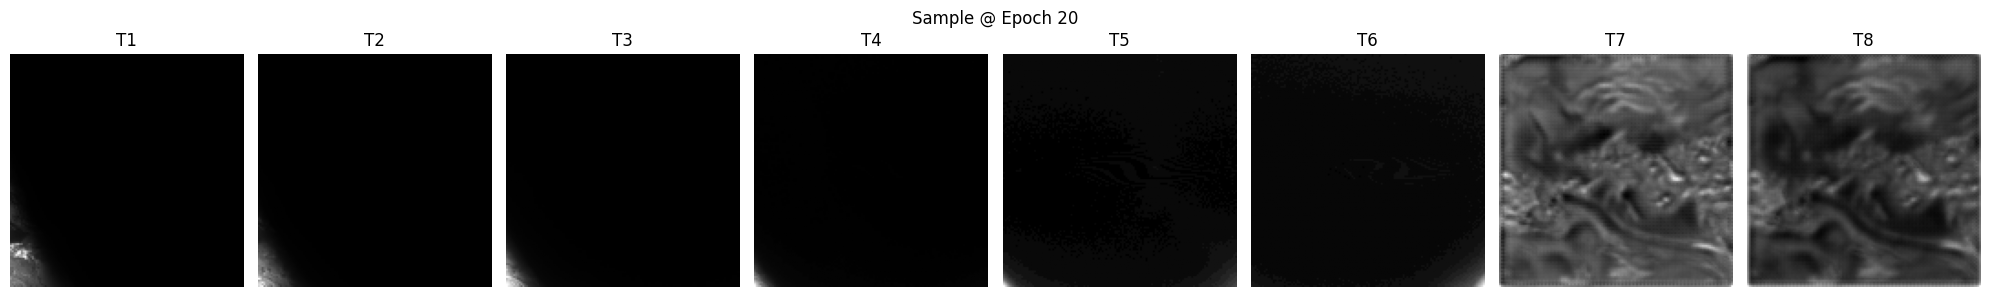

Epoch 21/40: 100%|██████████| 45/45 [00:44<00:00,  1.01it/s]


✅ Epoch 21 completed | Avg Loss: 0.0028


Epoch 22/40: 100%|██████████| 45/45 [00:51<00:00,  1.15s/it]


✅ Epoch 22 completed | Avg Loss: 0.0026


Epoch 23/40: 100%|██████████| 45/45 [00:51<00:00,  1.15s/it]


...

✅ Epoch 28 completed | Avg Loss: 0.0020


Epoch 29/40: 100%|██████████| 45/45 [00:51<00:00,  1.14s/it]


✅ Epoch 29 completed | Avg Loss: 0.0019


Epoch 30/40: 100%|██████████| 45/45 [00:50<00:00,  1.13s/it]


✅ Epoch 30 completed | Avg Loss: 0.0018
🌀 Generating sample @ epoch 30


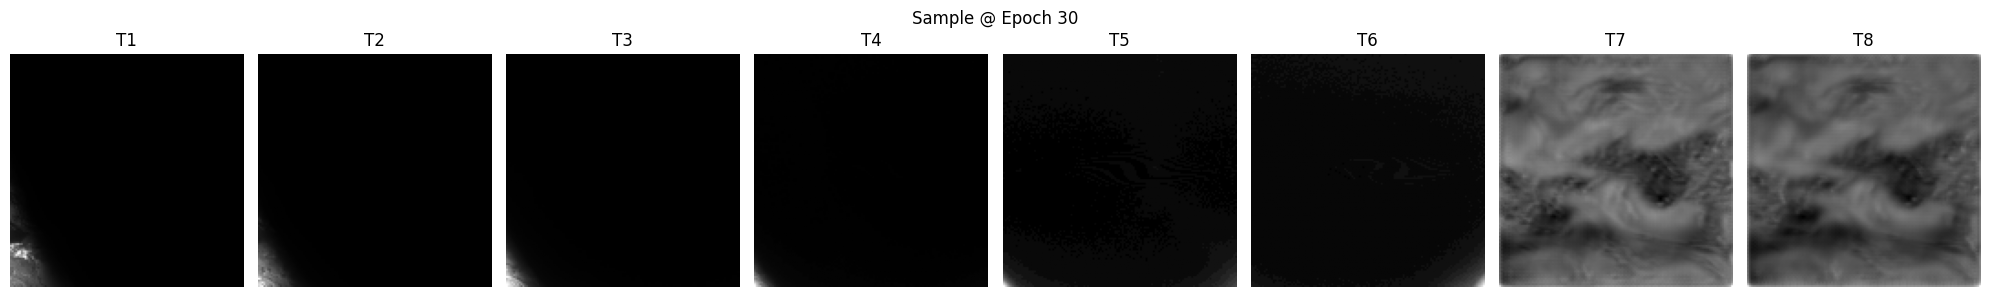

Epoch 31/40: 100%|██████████| 45/45 [00:44<00:00,  1.01it/s]


✅ Epoch 31 completed | Avg Loss: 0.0018


Epoch 32/40: 100%|██████████| 45/45 [00:50<00:00,  1.11s/it]


✅ Epoch 32 completed | Avg Loss: 0.0018


Epoch 33/40: 100%|██████████| 45/45 [00:49<00:00,  1.11s/it]


...

✅ Epoch 38 completed | Avg Loss: 0.0015


Epoch 39/40: 100%|██████████| 45/45 [00:51<00:00,  1.14s/it]


✅ Epoch 39 completed | Avg Loss: 0.0016


Epoch 40/40: 100%|██████████| 45/45 [00:52<00:00,  1.16s/it]


✅ Epoch 40 completed | Avg Loss: 0.0014
🌀 Generating sample @ epoch 40


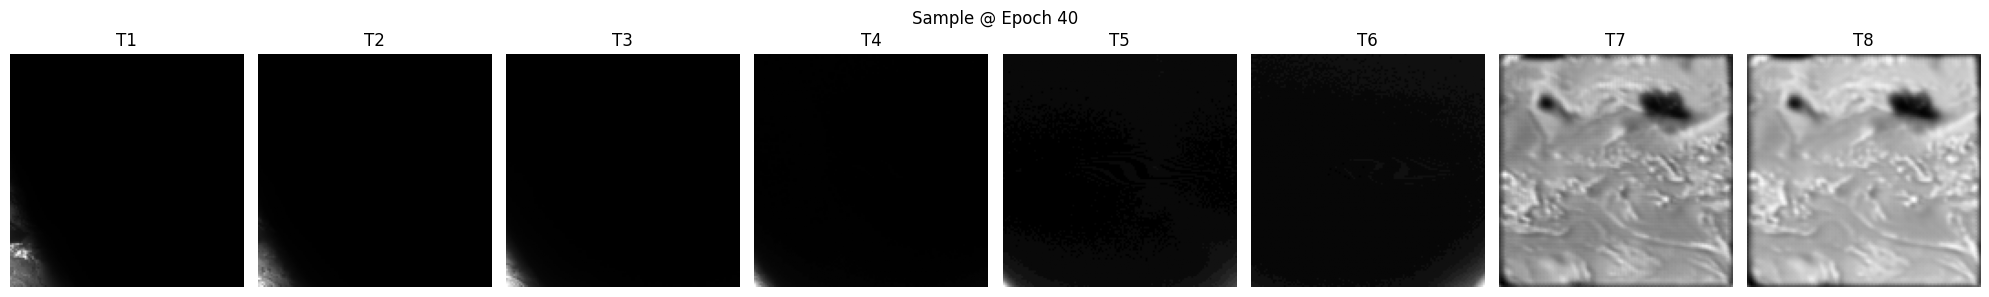

✅ Finished training and saved final checkpoint.


In [ ]:
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt

# === Hyperparameters ===
accum_steps  = 4
# start_epoch  = 0
# end_epoch    = 30
num_epochs   = end_epoch
CKPT_PATH    = "/content/drive/MyDrive/Model training/cloud_motion_diffusion_full_3D_UNet.pth"

# Select a fixed cond for visualization
fixed_cond = next(iter(dataloader))[0][:1].to(device)

for epoch in range(start_epoch, end_epoch):
    model.train()
    diffusion.train()
    running_loss = 0.0
    optimizer.zero_grad()

    for i, (cond, target) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        cond   = cond.to(device)
        target = target.to(device)

        # Plain FP32 forward/backward
        # loss = diffusion(cond, target) / accum_steps

        full_seq = torch.cat([cond, target], dim=1)  # (B, 8, C, H, W)
        loss = diffusion(full_seq) / accum_steps


        loss.backward()
        running_loss += loss.item() * accum_steps

        if (i + 1) % accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        torch.cuda.empty_cache()

    # leftover grads
    if (i + 1) % accum_steps != 0:
        optimizer.step()
        optimizer.zero_grad()

    avg_loss = running_loss / len(dataloader)
    print(f"✅ Epoch {epoch+1} completed | Avg Loss: {avg_loss:.4f}")

    # Save checkpoint
    torch.save({
        'model_state_dict':       model.state_dict(),
        'diffusion_state_dict':   diffusion.state_dict(),
        'optimizer_state_dict':   optimizer.state_dict(),
        'epoch':                  epoch + 1,
    }, CKPT_PATH)

    # Visualize every 10 epochs

    if (epoch + 1) % 10 == 0:
        print(f"🌀 Generating sample @ epoch {epoch+1}")
        with torch.no_grad():
            sample = diffusion.sample(cond=fixed_cond, batch_size=1).cpu()

            sample = sample.permute(0, 2, 1, 3, 4)  # (B, C, T, H, W)
            frames = sample[0, 0]  # Band 0 across time steps → (T=8, H, W)

            fig, axes = plt.subplots(1, 8, figsize=(20, 3))
            for t in range(8):
                axes[t].imshow(frames[t], cmap='gray')
                axes[t].axis('off')
                axes[t].set_title(f"T{t+1}")
            plt.suptitle(f"Sample @ Epoch {epoch+1}")
            plt.tight_layout()
            plt.show()



# Final save
torch.save({
    'model_state_dict':       model.state_dict(),
    'diffusion_state_dict':   diffusion.state_dict(),
    'optimizer_state_dict':   optimizer.state_dict(),
    'epoch':                  end_epoch,
}, "/content/drive/MyDrive/Model training/cloud_motion_diffusion_full_3D_UNet_final.pth")

print("✅ Finished training and saved final checkpoint.")


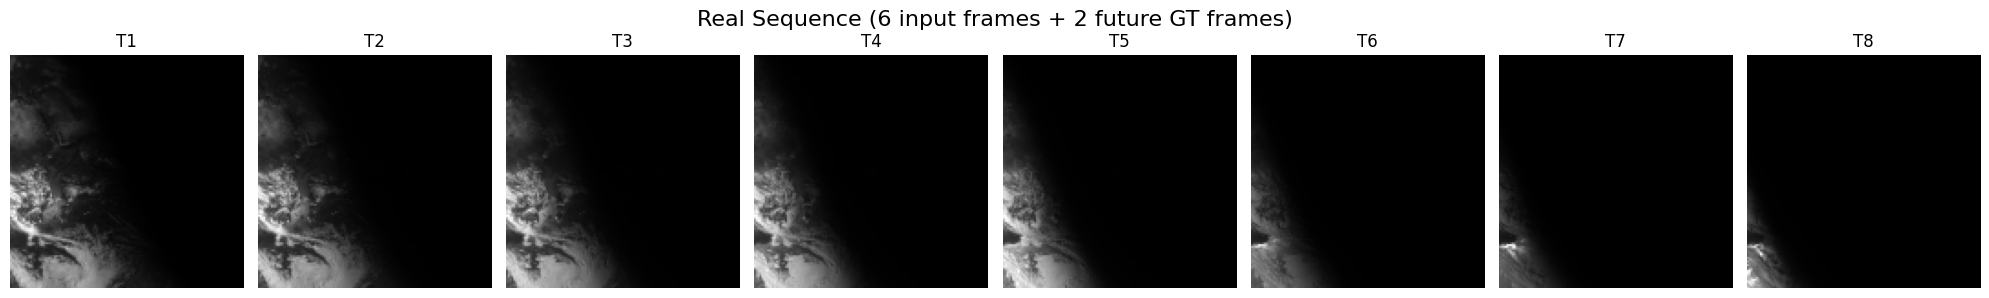

In [ ]:
import matplotlib.pyplot as plt

# Load a sample (cond: 6 frames, target: 2 frames)
sample_cond, sample_target = next(iter(dataloader))
sample_cond = sample_cond[0]   # shape: (6, 6, 128, 128)
sample_target = sample_target[0]  # shape: (2, 6, 128, 128)

# Combine for full sequence (8 frames)
sequence = torch.cat([sample_cond, sample_target], dim=0)  # (8, 6, 128, 128)

# Visualize only channel 0 for simplicity
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i in range(8):
    axes[i].imshow(sequence[i][0], cmap='gray')
    axes[i].set_title(f'T{i+1}')
    axes[i].axis('off')

plt.suptitle("Real Sequence (6 input frames + 2 future GT frames)", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
model.eval()
diffusion.eval()

# Use same `sample_cond` from previous cell
cond_input = sample_cond.unsqueeze(0).to(device)  # shape: (1, 6, 6, 128, 128)

# Generate prediction
with torch.no_grad():
    predicted_sequence = diffusion.sample(cond=cond_input, batch_size=1).cpu()

# Extract predicted 8 frames and split
predicted_full = predicted_sequence[0]  # (6+2, 6, 128, 128)
predicted_future = predicted_full[6:]   # last 2 frames


/tmp/ipython-input-23-247326246.py:22: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


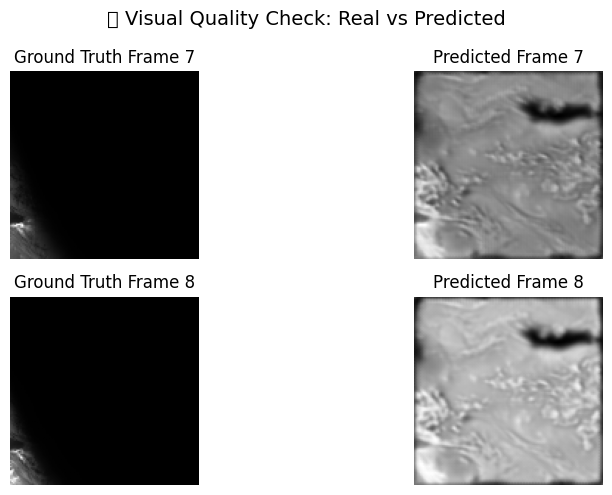

In [ ]:
# Ground truth future frames from the dataset (already normalized to [–1, 1])
ground_truth_future = sample_target  # shape: (2, 6, 128, 128)

# Take only the first channel for visual comparison (e.g. IMG_VIS)
gt_vis = ground_truth_future[:, 0]        # (2, 128, 128)
pred_vis = predicted_future[:, 0]         # (2, 128, 128)

# Plotting side-by-side comparisons
fig, axes = plt.subplots(2, 2, figsize=(10, 5))

titles = ['Frame 7', 'Frame 8']
for i in range(2):
    axes[i][0].imshow(gt_vis[i], cmap='gray')
    axes[i][0].set_title(f"Ground Truth {titles[i]}")
    axes[i][0].axis('off')

    axes[i][1].imshow(pred_vis[i], cmap='gray')
    axes[i][1].set_title(f"Predicted {titles[i]}")
    axes[i][1].axis('off')

plt.suptitle("🔍 Visual Quality Check: Real vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
with torch.no_grad():
    # Get a fresh real input + ground truth sample from the dataloader
    cond, target = next(iter(dataloader))
    cond = cond[:1].to(device)     # (1, 6, C, H, W)
    target = target[:1].to(device) # (1, 2, C, H, W)

    # Generate predicted T7 and T8
    sample = diffusion.sample(cond=cond, batch_size=1)  # shape: (1, 8, C, H, W)

    # Extract predicted frames: T7 and T8
    pred = sample[:, 6:]  # shape: (1, 2, C, H, W)

    # Print stats
    print("📊 Real T7/T8 stats:")
    for i in range(2):
        print(f"T{i+7}: min={target[0, i, 0].min().item():.4f}, max={target[0, i, 0].max().item():.4f}, mean={target[0, i, 0].mean().item():.4f}")

    print("\n📊 Predicted T7/T8 stats:")
    for i in range(2):
        print(f"T{i+7}: min={pred[0, i, 0].min().item():.4f}, max={pred[0, i, 0].max().item():.4f}, mean={pred[0, i, 0].mean().item():.4f}")


📊 Real T7/T8 stats:
T7: min=-0.9963, max=0.9184, mean=-0.7124
T8: min=-0.9963, max=1.0000, mean=-0.6692

📊 Predicted T7/T8 stats:
T7: min=-0.9603, max=0.8142, mean=-0.1321
T8: min=-0.9193, max=0.6891, mean=0.0715


In [ ]:
# 🔍 Preview VIS-band brightness across samples to find a daytime frame

import matplotlib.pyplot as plt

for i in range(10, 50):  # adjust range as needed
    cond, target = dataset[i]
    vis_band = cond[0, 0]  # First frame, VIS band

    mean_val = vis_band.mean().item()
    print(f"Sample {i} | VIS mean: {mean_val:.4f}")

    if mean_val > -0.2:  # likely a daytime frame (brightness > threshold)
        plt.imshow(vis_band, cmap='gray')
        plt.title(f"Sample {i} - VIS band (T1)")
        plt.colorbar()
        plt.show()
        break


Sample 10 | VIS mean: -0.7580
Sample 11 | VIS mean: -0.7407
Sample 12 | VIS mean: -0.7065
Sample 13 | VIS mean: -0.6998
Sample 14 | VIS mean: -0.5267
Sample 15 | VIS mean: -0.5079
Sample 16 | VIS mean: -0.6353
Sample 17 | VIS mean: -0.6657
Sample 18 | VIS mean: -0.6995
Sample 19 | VIS mean: -0.7310
Sample 20 | VIS mean: -0.7569
Sample 21 | VIS mean: -0.7829
Sample 22 | VIS mean: -0.8053
Sample 23 | VIS mean: -0.8237
Sample 24 | VIS mean: -0.8460
Sample 25 | VIS mean: -0.9011
Sample 26 | VIS mean: -0.9102
Sample 27 | VIS mean: -0.9213
Sample 28 | VIS mean: -0.9298
Sample 29 | VIS mean: -0.9387
Sample 30 | VIS mean: -0.9480
Sample 31 | VIS mean: -0.9574
Sample 32 | VIS mean: -0.9677
Sample 33 | VIS mean: -0.9776
Sample 34 | VIS mean: -0.9868
Sample 35 | VIS mean: -0.9824
Sample 36 | VIS mean: -0.9871
Sample 37 | VIS mean: -0.9886
Sample 38 | VIS mean: -0.9913
Sample 39 | VIS mean: -0.9909
Sample 40 | VIS mean: -0.9892
Sample 41 | VIS mean: -0.9834
Sample 42 | VIS mean: -0.9744
Sample 43 

In [ ]:
# ⚙️ Ensure model is in eval mode and on GPU
model.eval()
diffusion.eval()
model.to(device)
diffusion.to(device)

# 🧪 Load sample 14
cond, target = dataset[14]  # cond: (6, 6, 128, 128), target: (2, 6, 128, 128)
cond = cond.unsqueeze(0).to(device)  # shape: (1, 6, 6, 128, 128)

# 🔮 Generate predicted T7 and T8
with torch.no_grad():
    predicted = diffusion.sample(cond=cond, batch_size=1).cpu()  # shape: (1, 8, 6, 128, 128)


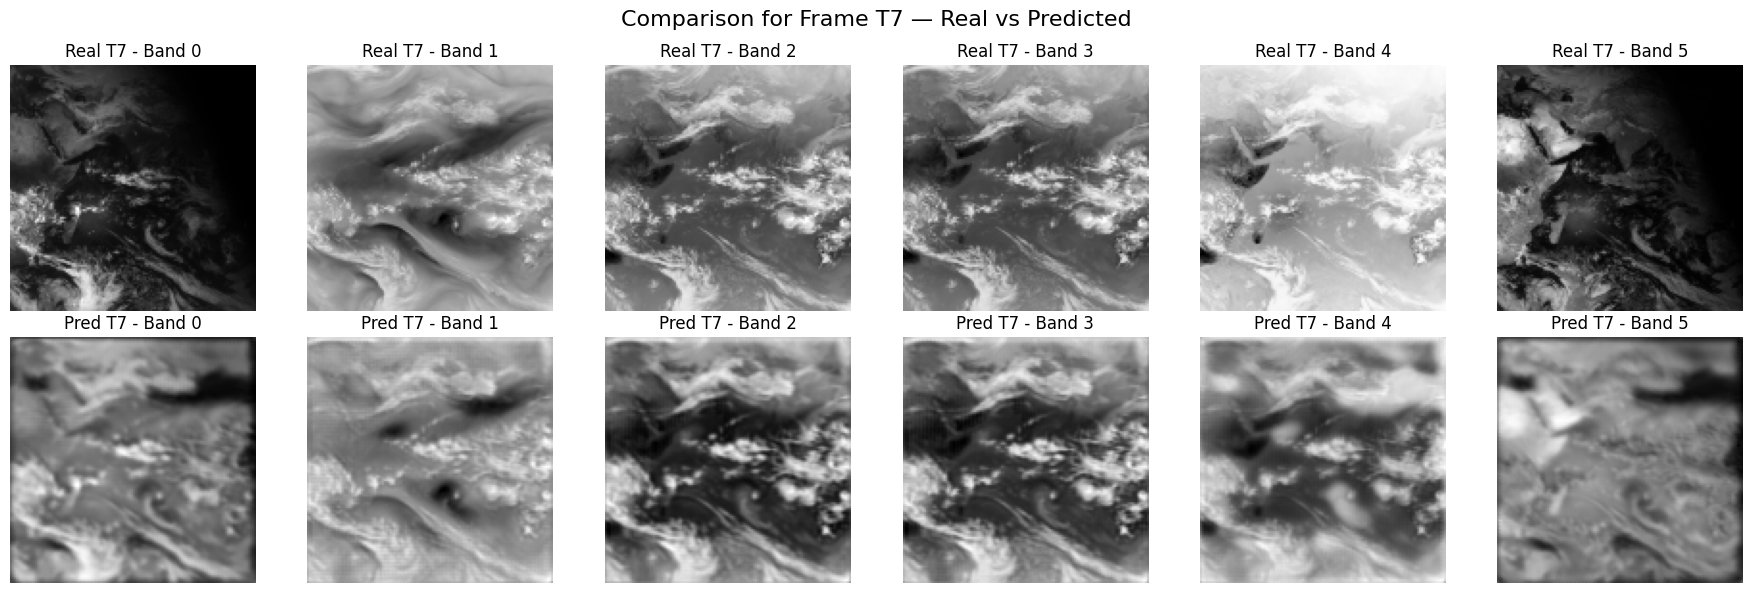

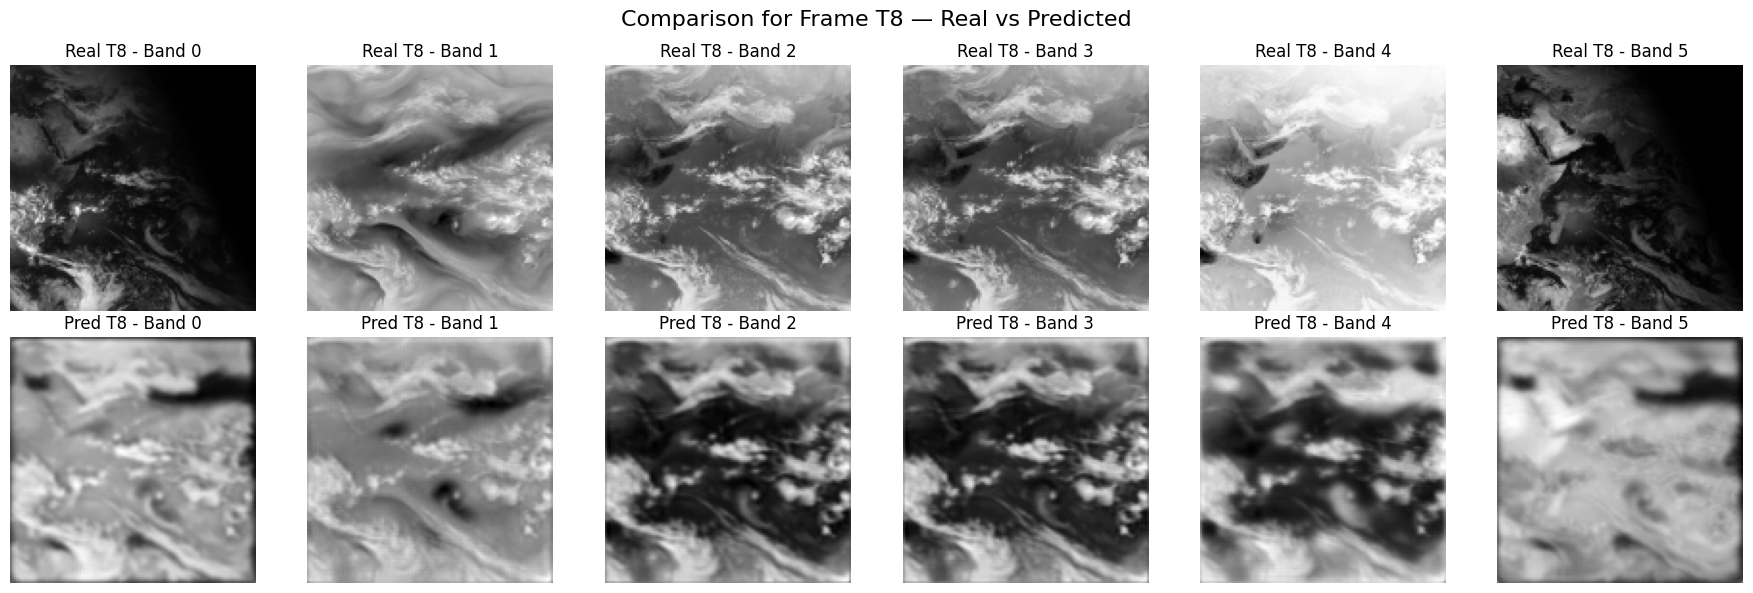

In [ ]:
import matplotlib.pyplot as plt

# 🎯 Extract real and predicted frames
real_t7 = target[0]      # (6, H, W)
real_t8 = target[1]      # (6, H, W)

pred_t7 = predicted[0, 6]  # (6, H, W)
pred_t8 = predicted[0, 7]  # (6, H, W)

# 🖼️ Plot
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for b in range(6):
    axes[0, b].imshow(real_t7[b], cmap='gray')
    axes[0, b].set_title(f"Real T7 - Band {b}")
    axes[0, b].axis('off')

    axes[1, b].imshow(pred_t7[b], cmap='gray')
    axes[1, b].set_title(f"Pred T7 - Band {b}")
    axes[1, b].axis('off')

plt.suptitle("Comparison for Frame T7 — Real vs Predicted", fontsize=16)
plt.tight_layout()
plt.show()

# Repeat for T8
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for b in range(6):
    axes[0, b].imshow(real_t8[b], cmap='gray')
    axes[0, b].set_title(f"Real T8 - Band {b}")
    axes[0, b].axis('off')

    axes[1, b].imshow(pred_t8[b], cmap='gray')
    axes[1, b].set_title(f"Pred T8 - Band {b}")
    axes[1, b].axis('off')

plt.suptitle("Comparison for Frame T8 — Real vs Predicted", fontsize=16)
plt.tight_layout()
plt.show()
